In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "datasets"

In [1]:
# Load libraries
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We load tidyverse library which is used for data manipulation and visualization in R.

In [3]:
list.files("/kaggle/input")
list.files("/kaggle/input/datasets")
list.files("/kaggle/input/datasets/nafeesalmahadi")


[1] "datasets"

[1] "nafeesalmahadi"

[1] "unicef-child-malnutrition-advance-analysis-dataset"

# **Data Loading**
Dataset contains 5220 observations and 41 variables.
It includes indicators related to child malnutrition such as stunting, wasting, underweight, and socio-economic factors.
Before analysis, data cleaning and exploratory data analysis are required to ensure accuracy and reliability.

In [4]:
list.files("/kaggle/input/datasets/nafeesalmahadi/unicef-child-malnutrition-advance-analysis-dataset")
list.files("/kaggle/input/datasets/nafeesalmahadi/unicef-child-malnutrition-advance-analysis-dataset/unicef_dataset")

[1] "unicef_dataset"

[1] "covid_analysis_overweight.csv"         
 [2] "covid_analysis_stunting.csv"           
 [3] "covid_analysis_underweight.csv"        
 [4] "covid_analysis_wasting.csv"            
 [5] "covid_yearly_tracking_overweight.csv"  
 [6] "covid_yearly_tracking_stunting.csv"    
 [7] "covid_yearly_tracking_underweight.csv" 
 [8] "covid_yearly_tracking_wasting.csv"     
 [9] "feature_columns.txt"                   
[10] "food_shock_analysis_all_indicators.csv"
[11] "food_shock_analysis_overweight.csv"    
[12] "food_shock_analysis_stunting.csv"      
[13] "food_shock_analysis_underweight.csv"   
[14] "food_shock_analysis_wasting.csv"       
[15] "malnutrition_engineered_dataset.csv"   
[16] "master_malnutrition_dataset.csv"       
[17] "overweight_dataset.csv"                
[18] "stunting_dataset.csv"                  
[19] "underweight_dataset.csv"               
[20] "wasting_dataset.csv"

In [5]:
data <- read.csv("/kaggle/input/datasets/nafeesalmahadi/unicef-child-malnutrition-advance-analysis-dataset/unicef_dataset/malnutrition_engineered_dataset.csv")
head(data)
str(data)
summary(data)

,ISO_code,year,stunting_prevalence,country,overweight_prevalence,wasting_prevalence,wasting_footnote,underweight_prevalence,un_region,wasting_imputed,⋯,overweight_prevalence_lag_2,overweight_prevalence_lag_3,overweight_prevalence_rolling_3,overweight_prevalence_rolling_5,overweight_prevalence_delta,region_code,is_ldc,covid_period,recovery_flag,food_price_shock
,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>
1,AFG,2000,55.5,Afghanistan,4.8,7.55,,22.90,Asia,0,⋯,0.0,0.0,4.800000,4.800000,0.0,1,1,0,0,0
2,AFG,2001,55.2,Afghanistan,4.9,10.20,,17.85,Asia,0,⋯,0.0,0.0,4.850000,4.850000,0.1,1,1,0,0,0
3,AFG,2002,54.4,Afghanistan,4.9,8.35,,12.80,Asia,0,⋯,4.8,0.0,4.866667,4.866667,0.0,1,1,0,0,0
4,AFG,2003,53.4,Afghanistan,5.0,8.00,,14.65,Asia,0,⋯,4.9,4.8,4.933333,4.900000,0.1,1,1,0,0,0
5,AFG,2004,52.4,Afghanistan,5.0,8.60,w 11,32.90,Asia,0,⋯,4.9,4.9,4.966667,4.920000,0.0,1,1,0,0,0
6,AFG,2005,51.3,Afghanistan,5.0,8.60,,32.90,Asia,0,⋯,5.0,4.9,5.000000,4.960000,0.0,1,1,0,0,0


'data.frame':	5220 obs. of  41 variables:
 $ ISO_code                        : chr  "AFG" "AFG" "AFG" "AFG" ...
 $ year                            : int  2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 ...
 $ stunting_prevalence             : num  55.5 55.2 54.4 53.4 52.4 51.3 50.3 49 47.8 46.5 ...
 $ country                         : chr  "Afghanistan" "Afghanistan" "Afghanistan" "Afghanistan" ...
 $ overweight_prevalence           : num  4.8 4.9 4.9 5 5 5 5 5 4.9 4.9 ...
 $ wasting_prevalence              : num  7.55 10.2 8.35 8 8.6 8.6 8.6 8.6 8.6 8.6 ...
 $ wasting_footnote                : chr  "" "" "" "" ...
 $ underweight_prevalence          : num  22.9 17.9 12.8 14.6 32.9 ...
 $ un_region                       : chr  "Asia" "Asia" "Asia" "Asia" ...
 $ wasting_imputed                 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ underweight_imputed             : int  0 0 0 0 0 0 0 0 0 0 ...
 $ split                           : chr  "train" "train" "train" "train" ...
 $ stunting_prevalen

   ISO_code              year      stunting_prevalence   country         
 Length:5220        Min.   :2000   Min.   : 0.90       Length:5220       
 Class :character   1st Qu.:2006   1st Qu.: 9.00       Class :character  
 Mode  :character   Median :2012   Median :18.10       Mode  :character  
                    Mean   :2012   Mean   :20.23                         
                    3rd Qu.:2018   3rd Qu.:28.60                         
                    Max.   :2024   Max.   :63.00                         
 overweight_prevalence wasting_prevalence wasting_footnote  
 Min.   : 0.60         Min.   : 0.000     Length:5220       
 1st Qu.: 3.80         1st Qu.: 2.975     Class :character  
 Median : 5.70         Median : 4.700     Mode  :character  
 Mean   : 6.46         Mean   : 5.615                       
 3rd Qu.: 8.10         3rd Qu.: 7.500                       
 Max.   :28.70         Max.   :24.600                       
 underweight_prevalence  un_region         wasting_impu

# **Data Cleaning**
Missing value analysis helps identify incomplete information in the dataset before performing statistical analysis and visualization.

In [6]:
#data cleaning
colSums(is.na(data))    #Missing value analysis helps identify incomplete information in the dataset before performing statistical analysis and visualization.                        
missing_percent <- colSums(is.na(data)) / nrow(data) * 100      #Percentage of missing values helps determine whether variables should be removed or imputed.

missing_percent
#remove missing valuues
data_clean <- na.omit(data)
#data size after cleaning
dim(data_clean)
#check duplicate rows
sum(duplicated(data_clean))
#remove duplicates
data_clean <- distinct(data_clean)       #remove duplicate rows to improve data quality and consistency.
#final structure of clean data
str(data_clean)
summary(data_clean)



ISO_code                             year 
                               0                                0 
             stunting_prevalence                          country 
                               0                                0 
           overweight_prevalence               wasting_prevalence 
                               0                                0 
                wasting_footnote           underweight_prevalence 
                               0                                0 
                       un_region                  wasting_imputed 
                               0                                0 
             underweight_imputed                            split 
                               0                                0 
       stunting_prevalence_lag_1        stunting_prevalence_lag_2 
                               0                                0 
       stunting_prevalence_lag_3    stunting_prevalence_rolling_3 
                               0                                0 
   stunting_prevalence_rolling_5        stunting_prevalence_delta 
                               0                                0 
        wasting_prevalence_lag_1         wasting_prevalence_lag_2 
                               0                                0 
        wasting_prevalence_lag_3     wasting_prevalence_rolling_3 
                               0                                0 
    wasting_prevalence_rolling_5         wasting_prevalence_delta 
                               0                                0 
    underweight_prevalence_lag_1     underweight_prevalence_lag_2 
                               0                                0 
    underweight_prevalence_lag_3 underweight_prevalence_rolling_3 
                               0                                0 
underweight_prevalence_rolling_5     underweight_prevalence_delta 
                               0                                0 
     overweight_prevalence_lag_1      overweight_prevalence_lag_2 
                               0                                0 
     overweight_prevalence_lag_3  overweight_prevalence_rolling_3 
                               0                                0 
 overweight_prevalence_rolling_5      overweight_prevalence_delta 
                               0                                0 
                     region_code                           is_ldc 
                               0                                0 
                    covid_period                    recovery_flag 
                               0                                0 
                food_price_shock 
                               0

ISO_code                             year 
                               0                                0 
             stunting_prevalence                          country 
                               0                                0 
           overweight_prevalence               wasting_prevalence 
                               0                                0 
                wasting_footnote           underweight_prevalence 
                               0                                0 
                       un_region                  wasting_imputed 
                               0                                0 
             underweight_imputed                            split 
                               0                                0 
       stunting_prevalence_lag_1        stunting_prevalence_lag_2 
                               0                                0 
       stunting_prevalence_lag_3    stunting_prevalence_rolling_3 
                               0                                0 
   stunting_prevalence_rolling_5        stunting_prevalence_delta 
                               0                                0 
        wasting_prevalence_lag_1         wasting_prevalence_lag_2 
                               0                                0 
        wasting_prevalence_lag_3     wasting_prevalence_rolling_3 
                               0                                0 
    wasting_prevalence_rolling_5         wasting_prevalence_delta 
                               0                                0 
    underweight_prevalence_lag_1     underweight_prevalence_lag_2 
                               0                                0 
    underweight_prevalence_lag_3 underweight_prevalence_rolling_3 
                               0                                0 
underweight_prevalence_rolling_5     underweight_prevalence_delta 
                               0                                0 
     overweight_prevalence_lag_1      overweight_prevalence_lag_2 
                               0                                0 
     overweight_prevalence_lag_3  overweight_prevalence_rolling_3 
                               0                                0 
 overweight_prevalence_rolling_5      overweight_prevalence_delta 
                               0                                0 
                     region_code                           is_ldc 
                               0                                0 
                    covid_period                    recovery_flag 
                               0                                0 
                food_price_shock 
                               0

[1] 5220   41

[1] 0

'data.frame':	5220 obs. of  41 variables:
 $ ISO_code                        : chr  "AFG" "AFG" "AFG" "AFG" ...
 $ year                            : int  2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 ...
 $ stunting_prevalence             : num  55.5 55.2 54.4 53.4 52.4 51.3 50.3 49 47.8 46.5 ...
 $ country                         : chr  "Afghanistan" "Afghanistan" "Afghanistan" "Afghanistan" ...
 $ overweight_prevalence           : num  4.8 4.9 4.9 5 5 5 5 5 4.9 4.9 ...
 $ wasting_prevalence              : num  7.55 10.2 8.35 8 8.6 8.6 8.6 8.6 8.6 8.6 ...
 $ wasting_footnote                : chr  "" "" "" "" ...
 $ underweight_prevalence          : num  22.9 17.9 12.8 14.6 32.9 ...
 $ un_region                       : chr  "Asia" "Asia" "Asia" "Asia" ...
 $ wasting_imputed                 : int  0 0 0 0 0 0 0 0 0 0 ...
 $ underweight_imputed             : int  0 0 0 0 0 0 0 0 0 0 ...
 $ split                           : chr  "train" "train" "train" "train" ...
 $ stunting_prevalen

   ISO_code              year      stunting_prevalence   country         
 Length:5220        Min.   :2000   Min.   : 0.90       Length:5220       
 Class :character   1st Qu.:2006   1st Qu.: 9.00       Class :character  
 Mode  :character   Median :2012   Median :18.10       Mode  :character  
                    Mean   :2012   Mean   :20.23                         
                    3rd Qu.:2018   3rd Qu.:28.60                         
                    Max.   :2024   Max.   :63.00                         
 overweight_prevalence wasting_prevalence wasting_footnote  
 Min.   : 0.60         Min.   : 0.000     Length:5220       
 1st Qu.: 3.80         1st Qu.: 2.975     Class :character  
 Median : 5.70         Median : 4.700     Mode  :character  
 Mean   : 6.46         Mean   : 5.615                       
 3rd Qu.: 8.10         3rd Qu.: 7.500                       
 Max.   :28.70         Max.   :24.600                       
 underweight_prevalence  un_region         wasting_impu

In [7]:
library(dplyr)
library(ggplot2)

top_stunting <- data_clean %>%
  group_by(country) %>%
  summarise(avg_stunting = mean(stunting_prevalence, na.rm = TRUE)) %>%
  arrange(desc(avg_stunting)) %>%
  slice(1:10)

top_stunting

country,avg_stunting
<chr>,<dbl>
Burundi,56.74643
Timor-Leste,51.73600
Yemen,49.88800
Eritrea,48.74000
Madagascar,48.56071
Guatemala,48.24643
Niger,47.08824
Afghanistan,45.92800
Papua New Guinea,45.34800


# **Exploratory Data Analysis**
This analysis identifies countries with the highest average stunting prevalence, highlighting regions facing severe child malnutrition challenges.

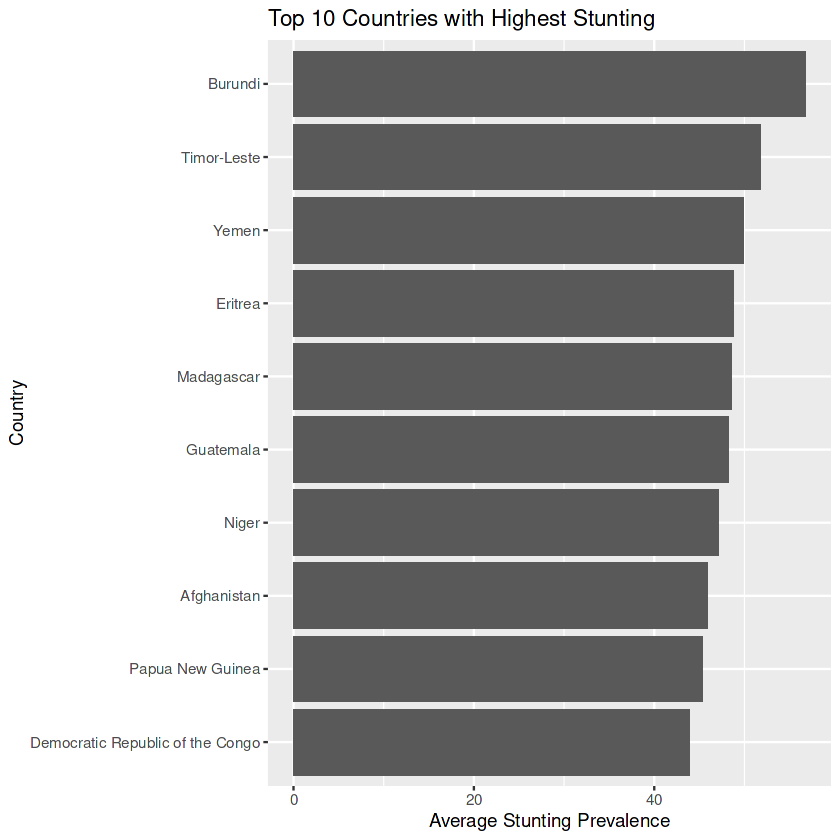

In [8]:
ggplot(top_stunting,
       aes(x = reorder(country, avg_stunting),
           y = avg_stunting)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Top 10 Countries with Highest Stunting",
    x = "Country",
    y = "Average Stunting Prevalence"
  )

In [9]:
ggsave("top_stunting_chart.png")

Saving 7 x 7 in image


# **Yearly Trend Analysis**
This analysis shows how child stunting has changed over time globally, helping identify long-term trends.

In [10]:
yearly_stunting <- data_clean %>%
  group_by(year) %>%
  summarise(avg_stunting = mean(stunting_prevalence, na.rm = TRUE))

yearly_stunting

year,avg_stunting
<int>,<dbl>
2000,24.39327
2001,23.70927
2002,23.57772
2003,23.31931
2004,23.50049
2005,23.12488
2006,22.80780
2007,22.02475
2008,21.56238


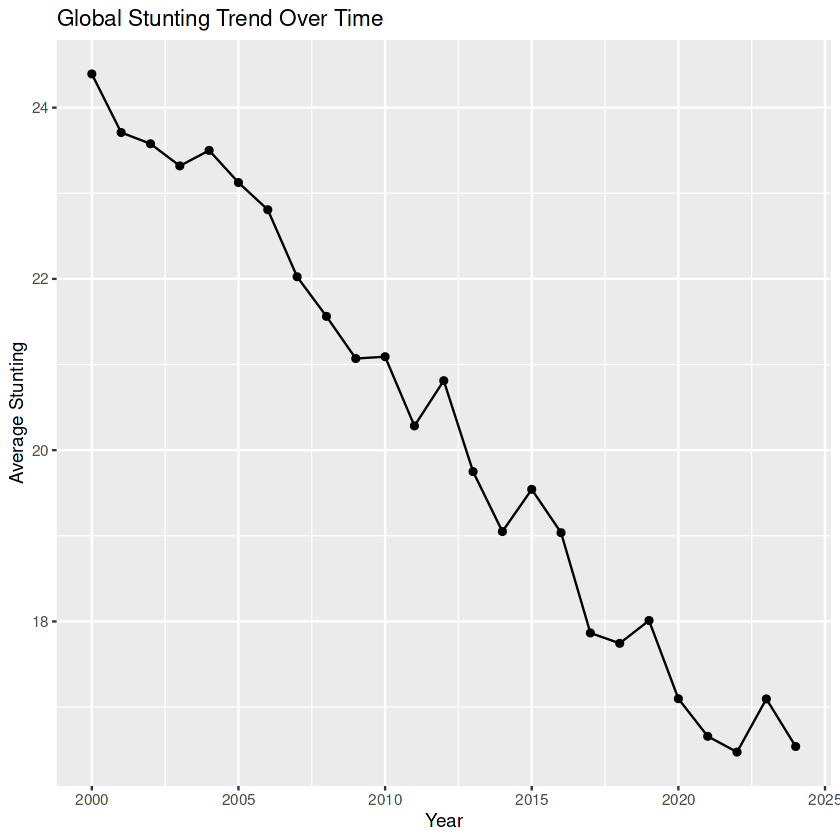

In [11]:
#line graph
ggplot(yearly_stunting, aes(x = year, y = avg_stunting)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Global Stunting Trend Over Time",
    x = "Year",
    y = "Average Stunting"
  )


In [12]:
ggsave("yearly_stunting_graph.png")

Saving 7 x 7 in image


# **Regional Analysis**
Regional analysis helps compare malnutrition indicators across continents.

In [13]:
#region-wise comparison
region_analysis <- data_clean %>%
  group_by(un_region) %>%
  summarise(
    stunting = mean(stunting_prevalence, na.rm = TRUE),
    wasting = mean(wasting_prevalence, na.rm = TRUE),
    underweight = mean(underweight_prevalence, na.rm = TRUE)
  )

region_analysis

un_region,stunting,wasting,underweight
<chr>,<dbl>,<dbl>,<dbl>
Africa,30.437171,7.817996,17.671810
Asia,21.474651,7.134701,13.937449
Europe,7.497541,3.373156,2.915710
Latin America and the Caribbean,14.382368,2.766216,5.406821
Northern America,10.532000,0.356000,0.768000
Oceania,18.955273,4.705636,8.501818
Other,18.100000,4.700000,8.600000


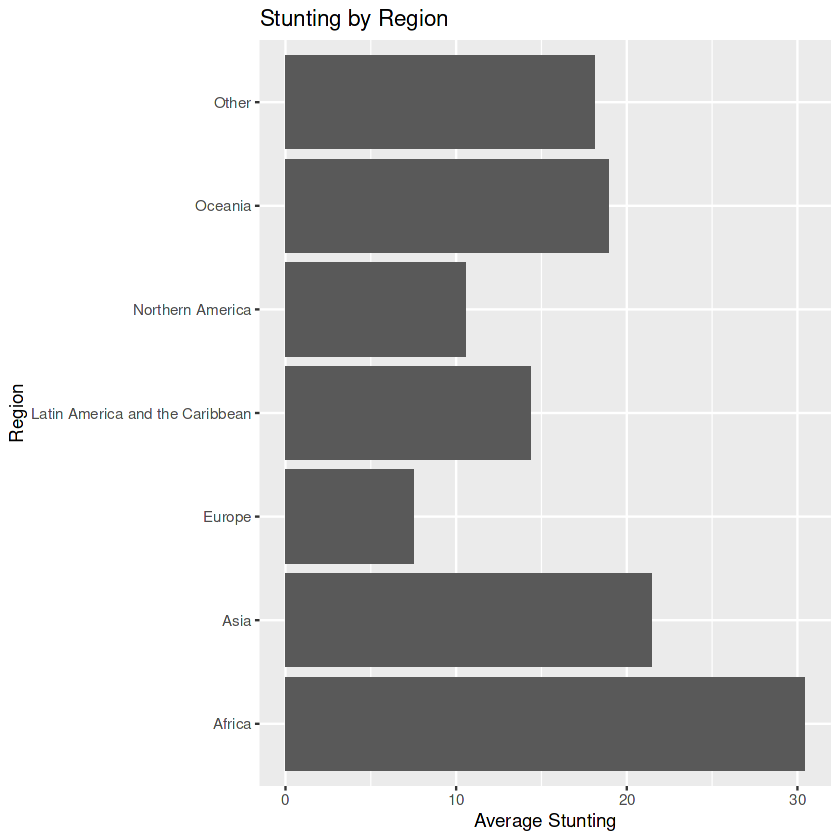

In [14]:
#bar chart
ggplot(region_analysis, aes(x = un_region, y = stunting)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Stunting by Region",
    x = "Region",
    y = "Average Stunting"
  )


In [15]:
ggsave("region_analysis_chart.png")

Saving 7 x 7 in image


# **COVID impact analysis**


In [16]:
#before vs during COVID
covid_analysis <- data_clean %>%
  group_by(covid_period) %>%
  summarise(avg_stunting = mean(stunting_prevalence, na.rm = TRUE))

covid_analysis

covid_period,avg_stunting
<int>,<dbl>
0,20.69711
1,16.74588


function (data = NULL, mapping = aes(), ..., environment = parent.frame()) 
{
    UseMethod("ggplot")
}
<bytecode: 0x58aaf9018508>
<environment: namespace:ggplot2>

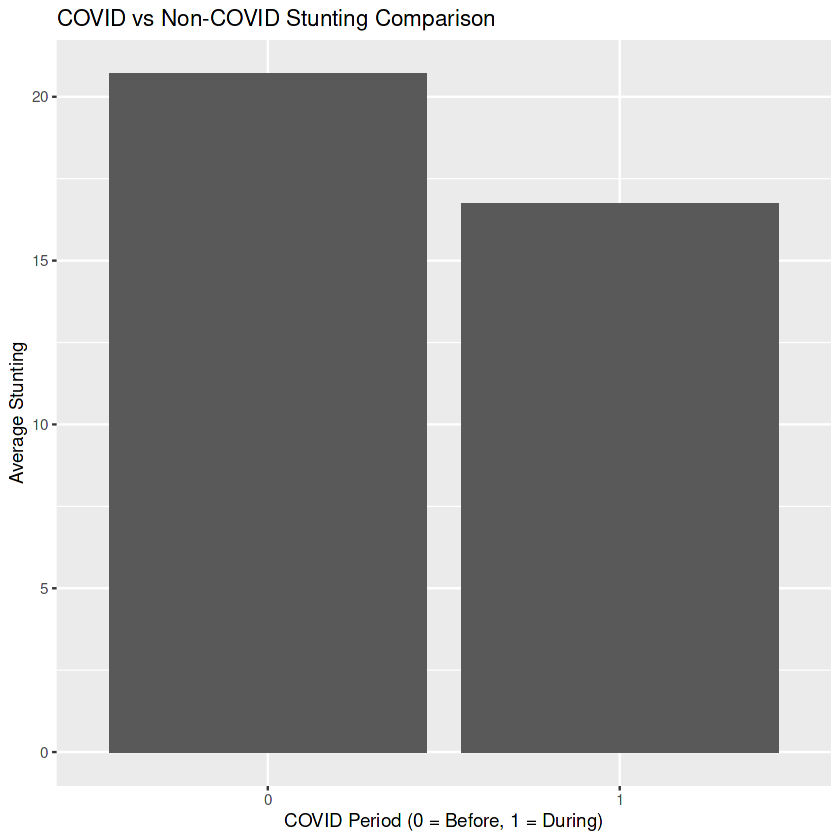

In [17]:
ggplot(covid_analysis, aes(x = factor(covid_period), y = avg_stunting)) +
  geom_bar(stat = "identity") +
  labs(
    title = "COVID vs Non-COVID Stunting Comparison",
    x = "COVID Period (0 = Before, 1 = During)",
    y = "Average Stunting"
  )
ggplot


In [18]:
ggsave("covid_analysis_plot.png")

Saving 7 x 7 in image


# **Correlation Analysis**
Correlation analysis shows relationships between different malnutrition indicators.

In [19]:
numeric_cols <- data_clean %>%
  select(stunting_prevalence, wasting_prevalence, underweight_prevalence, overweight_prevalence)

cor(numeric_cols)

,stunting_prevalence,wasting_prevalence,underweight_prevalence,overweight_prevalence
stunting_prevalence,1.0000000,0.5798984,0.8274982,-0.3257112
wasting_prevalence,0.5798984,1.0000000,0.8288015,-0.2838230
underweight_prevalence,0.8274982,0.8288015,1.0000000,-0.4575047
overweight_prevalence,-0.3257112,-0.2838230,-0.4575047,1.0000000
